# Road Accident Dataset - Data Cleaning Project

## Objective
This notebook focuses on cleaning and preparing a road accident dataset for further analysis.

The cleaning process includes:
- Data understanding
- Handling missing values
- Removing duplicates
- Data consistency checking
- Text cleaning
- Outlier detection
- Final data validation

*Installing needed LIBRARIES *

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading Dataset

In this section, we load the dataset and create a DataFrame to start the cleaning process.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving RTA Dataset.csv to RTA Dataset.csv


In [3]:
uploaded.keys()

dict_keys(['RTA Dataset.csv'])

In [5]:
df = pd.read_csv("RTA Dataset.csv")

# 2. Initial Data Exploration

Before cleaning, we inspect the dataset structure, columns, data types, and basic statistics.

In [6]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [7]:
df.tail()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,...,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


In [8]:
df.shape

(12316, 32)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [9]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [10]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


Missing Values

# 3. Missing Values Analysis

Missing values can affect the quality of analysis.
First, we identify columns containing missing data.

In [12]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


## Handling Missing Values

Most columns are categorical variables, therefore missing values are replaced using the mode value of each column.

In [14]:
# Get columns with missing values
missing_cols = df.columns[df.isnull().sum() > 0]

# Fill missing values with mode
for col in missing_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check if missing values are gone
df.isnull().sum()

/tmp/ipykernel_4607/2601245939.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


In [15]:
missing_cols = df.columns[df.isnull().sum() > 0]

for col in missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


Duplicate Values

# 4. Duplicate Data Detection

Duplicate records can affect the accuracy of analysis, so we check and remove duplicated rows.

In [17]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.drop_duplicates(inplace=True)

In [33]:
df.duplicated().sum()

np.int64(0)

Text Cleaning

# 5. Text Data Cleaning

Text columns may contain extra spaces or inconsistent formatting.
We standardize text values to improve consistency.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            12316 non-null  object
 5   Vehicle_driver_relation      12316 non-null  object
 6   Driving_experience           12316 non-null  object
 7   Type_of_vehicle              12316 non-null  object
 8   Owner_of_vehicle             12316 non-null  object
 9   Service_year_of_vehicle      12316 non-null  object
 10  Defect_of_vehicle            12316 non-null  object
 11  Area_accident_occured        12316 non-null  object
 12  Lanes_or_Medians             12316 non-null  object
 13  Road_allignment              12

In [19]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [34]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower()

Categorical Inspection

# 6. Categorical Variables Analysis

We examine unique values in categorical columns to detect inconsistent entries.

In [20]:
for col in df.select_dtypes(include="object").columns:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: Time
Time
15:30:00    120
17:10:00    110
18:30:00    103
11:30:00     99
17:00:00     98
           ... 
0:52:00       1
4:49:00       1
14:31:00      1
19:18:00      1
2:47:00       1
Name: count, Length: 1074, dtype: int64

Column: Day_of_week
Day_of_week
Friday       2041
Thursday     1851
Wednesday    1840
Tuesday      1770
Monday       1681
Saturday     1666
Sunday       1467
Name: count, dtype: int64

Column: Age_band_of_driver
Age_band_of_driver
18-30       4271
31-50       4087
Over 51     1585
Unknown     1548
Under 18     825
Name: count, dtype: int64

Column: Sex_of_driver
Sex_of_driver
Male       11437
Female       701
Unknown      178
Name: count, dtype: int64

Column: Educational_level
Educational_level
Junior high school    8360
Elementary school     2163
High school           1110
Above high school      362
Writing & reading      176
Unknown                100
Illiterate              45
Name: count, dtype: int64

Column: Vehicle_driver_relation
Vehicle_driver_

Outliers

# 7. Outlier Detection

Outliers are detected using boxplots for numerical variables.

In [21]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


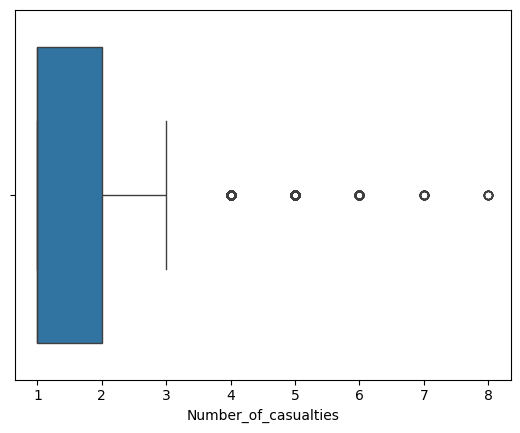

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Number_of_casualties"])
plt.show()

In [24]:
Q1 = df["Number_of_casualties"].quantile(0.25)
Q3 = df["Number_of_casualties"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["Number_of_casualties"] >= lower) &
    (df["Number_of_casualties"] <= upper)
]

## Removing Outliers Using IQR Method

In [25]:
df[df["Number_of_vehicles_involved"] <= 0]

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity


In [26]:
df[df["Number_of_casualties"] <= 0]

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11596 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         11596 non-null  object
 1   Day_of_week                  11596 non-null  object
 2   Age_band_of_driver           11596 non-null  object
 3   Sex_of_driver                11596 non-null  object
 4   Educational_level            11596 non-null  object
 5   Vehicle_driver_relation      11596 non-null  object
 6   Driving_experience           11596 non-null  object
 7   Type_of_vehicle              11596 non-null  object
 8   Owner_of_vehicle             11596 non-null  object
 9   Service_year_of_vehicle      11596 non-null  object
 10  Defect_of_vehicle            11596 non-null  object
 11  Area_accident_occured        11596 non-null  object
 12  Lanes_or_Medians             11596 non-null  object
 13  Road_allignment              11596 n

In [28]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


In [29]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,11596.000000,11596.000000
mean,2.017679,1.354260
std,0.674898,0.620944
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,3.000000


Final Validation

# 8. Final Data Validation

After cleaning, we verify that:
- Missing values are handled
- Duplicate records are removed
- Data types are correct
- Dataset is ready for analysis

In [35]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,monday,18-30,male,above high school,employee,1-2yr,automobile,owner,above 10yr,...,going straight,na,na,na,na,driver,normal,not a pedestrian,moving backward,slight injury
1,17:02:00,monday,31-50,male,junior high school,employee,above 10yr,public (> 45 seats),owner,5-10yrs,...,going straight,na,na,na,na,driver,normal,not a pedestrian,overtaking,slight injury
2,17:02:00,monday,18-30,male,junior high school,employee,1-2yr,lorry (41?100q),owner,unknown,...,going straight,driver or rider,male,31-50,3,driver,normal,not a pedestrian,changing lane to the left,serious injury
3,1:06:00,sunday,18-30,male,junior high school,employee,5-10yr,public (> 45 seats),governmental,unknown,...,going straight,pedestrian,female,18-30,3,driver,normal,not a pedestrian,changing lane to the right,slight injury
4,1:06:00,sunday,18-30,male,junior high school,employee,2-5yr,automobile,owner,5-10yrs,...,going straight,na,na,na,na,driver,normal,not a pedestrian,overtaking,slight injury


Export

# 9. Export Clean Dataset

The cleaned dataset is saved as a new CSV file for future analysis.

In [31]:
df.to_csv("clean_accident_data.csv", index=False)